# Stock Prediction — Exploration

Walks through the same pipeline the CLI/API use, but interactively: fetch combined data, inspect indicators, train, and evaluate.

Run from the project root with the venv's kernel: `python -m ipykernel install --user --name stockpred` (once), or just `jupyter notebook` from an activated venv.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
from app.data.aggregator import DataAggregator, default_lookback_start
from app.features.build_features import build_feature_frame, build_training_dataset

TICKER = "AAPL"

In [2]:
aggregator = DataAggregator()
print("Configured sources:", aggregator.available_sources())

ohlcv, status = aggregator.fetch(TICKER, start=default_lookback_start(5))
print(status)
ohlcv.tail()

Cookie fetch from fc.yahoo.com failed (CertificateVerifyError), continuing without it


Configured sources: ['yfinance', 'alpha_vantage', 'polygon']


Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19).

{'alpha_vantage': 'ok', 'polygon': 'ok', 'yfinance': "yfinance returned no data for 'AAPL' after retrying two call paths. This is usually transient Yahoo rate-limiting — try again in a minute, or run `pip install --upgrade yfinance`. Last error: provider returned an empty result (likely bot-detection/rate-limiting)"}


,open,high,low,close,volume
date,,,,,
2026-09-01,316.980,327.30,314.73,325.13,5.316739e+07
2026-09-02,326.865,328.40,323.53,324.96,3.377637e+07
2026-09-03,324.870,330.81,324.11,328.21,3.722584e+07
2026-09-04,328.305,328.93,317.86,319.97,3.960688e+07
2026-09-08,317.100,320.70,314.90,316.22,3.547709e+07


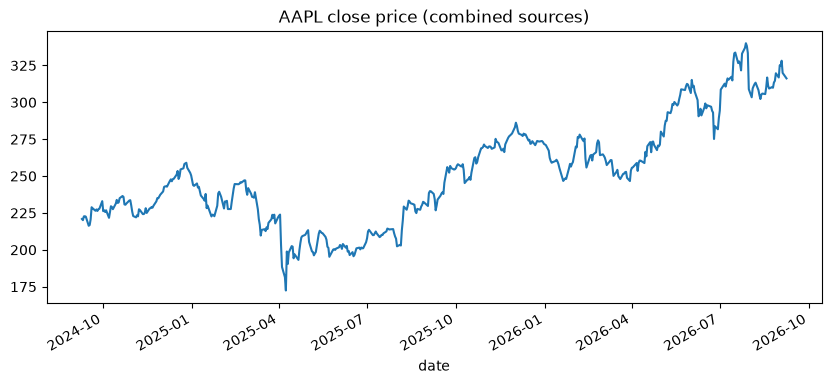

In [3]:
ohlcv["close"].plot(figsize=(10, 4), title=f"{TICKER} close price (combined sources)")
plt.show()

In [4]:
features = build_feature_frame(ohlcv)
features.tail()

,return_1d,return_5d,return_10d,sma_gap_5d,sma_gap_10d,sma_gap_20d,sma_gap_50d,ema_gap_12d,rsi_14d,macd,macd_signal,macd_hist,bollinger_bandwidth,volatility_10d,volatility_20d,volume_change,volume_zscore_20d
date,,,,,,,,,,,,,,,,,
2026-09-01,0.026132,0.049145,0.048705,0.022608,0.033002,0.044360,0.038956,0.031427,61.062045,0.003719,-0.000930,0.004648,0.071125,0.014036,0.011937,0.289134,1.604394
2026-09-02,-0.000523,0.036720,0.025660,0.014726,0.029801,0.041478,0.036382,0.026012,60.857372,0.005835,0.000423,0.005412,0.080995,0.012736,0.011938,-0.364716,-0.790898
2026-09-03,0.010001,0.043328,0.054321,0.016224,0.034557,0.049238,0.044407,0.030523,63.384200,0.008142,0.001963,0.006178,0.093139,0.010732,0.012055,0.102127,-0.287869
2026-09-04,-0.025106,0.000845,0.034330,-0.009454,0.005218,0.021811,0.015290,0.003932,53.886208,0.008102,0.003232,0.004871,0.095266,0.014118,0.013545,0.063962,-0.006569
2026-09-08,-0.011720,-0.001988,0.018947,-0.020681,-0.008395,0.008554,0.001329,-0.006637,50.199499,0.006961,0.004008,0.002953,0.094354,0.014916,0.013279,-0.104270,-0.501297


## Train + evaluate

Uses the same `train_ticker` the CLI/API call, so results here match what `stockpred train` / `POST /train` produce.

In [5]:
from app.models.train import train_ticker

bundle = train_ticker(TICKER)
bundle.metrics

Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
$AAPL: possibly delisted; no timezone found
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
$AAPL: possibly delisted; no timezone found
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more 

{'test_rows': 91,
 'classification_accuracy': 0.5165,
 'classification_f1': 0.5217,
 'regression_mae': 4.4903,
 'regression_directional_accuracy': 0.4725,
 'classification_roc_auc': 0.5585}

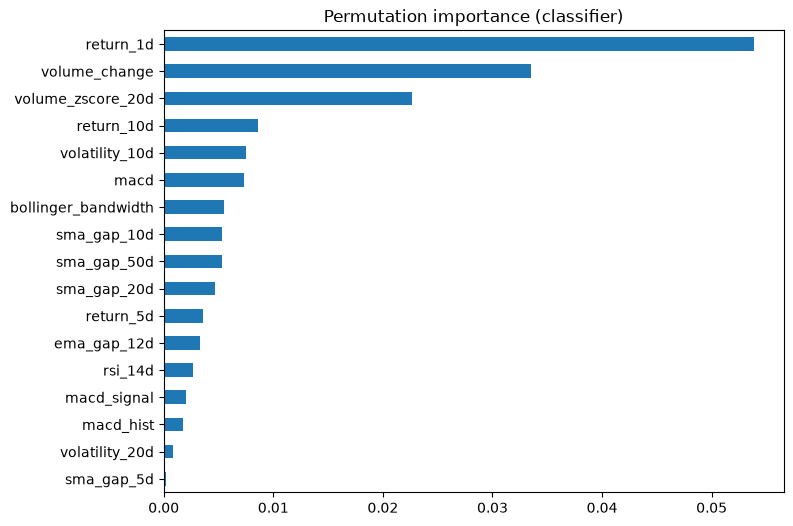

In [6]:
# Feature importance from the classifier (permutation importance is more reliable
# for HistGradientBoosting than the built-in attribute, which it doesn't expose).
from sklearn.inspection import permutation_importance

X, y_class, y_reg = build_training_dataset(ohlcv, bundle.horizon_days)
importance = permutation_importance(bundle.classifier, X, y_class, n_repeats=10, random_state=42)

import pandas as pd
importance_df = pd.Series(importance.importances_mean, index=X.columns).sort_values(ascending=False)
importance_df.plot.barh(figsize=(8, 6), title="Permutation importance (classifier)")
plt.gca().invert_yaxis()
plt.show()

In [7]:
from app.models.predict import predict_ticker

predict_ticker(TICKER)

Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
$AAPL: possibly delisted; no timezone found
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
$AAPL: possibly delisted; no timezone found
Cookie/crumb fetch failed (CertificateVerifyError), continuing without crumb
Failed to get ticker 'AAPL' reason: Failed to perform, curl: (60) SSL certificate OpenSSL verify result: self signed certificate in certificate chain (19). See https://curl.se/libcurl/c/libcurl-errors.html first for more 

Prediction(ticker='AAPL', horizon_days=1, as_of_date='2026-09-08', last_close=316.22, direction='fall', direction_confidence=0.5867, predicted_price=313.6596, predicted_change_pct=-0.8097, model_metrics={'test_rows': 91, 'classification_accuracy': 0.5165, 'classification_f1': 0.5217, 'regression_mae': 4.4903, 'regression_directional_accuracy': 0.4725, 'classification_roc_auc': 0.5585}, data_sources={'alpha_vantage': 'ok', 'polygon': 'ok', 'yfinance': "yfinance returned no data for 'AAPL' after retrying two call paths. This is usually transient Yahoo rate-limiting — try again in a minute, or run `pip install --upgrade yfinance`. Last error: provider returned an empty result (likely bot-detection/rate-limiting)"})